# 02 · FunnyBirds + CBM — grounding & mechanism

**Claim under test (CBM).** Concepts are a faithful bottleneck: a part concept
reflects *its part*. **Backwash** is the failure where a part concept instead
reads *species / the rest of the bird* — it reports a part it cannot see.

Two probes, read together:
- **Deletion grounding** (causal): remove a present part, does its concept stay
  high? `analysis/grounding_deletion.py` → `grounding/funnybirds-cbm-s*.parquet`.
- **Species probe** (mechanism): is the bottleneck a species code?
  `analysis/species_probe.py` → `species_probe/funnybirds-cbm-s*.json`.

Reference (outside curated, method source): `fb_cbm_renderer_swap_v2.ipynb`
(z-ordering / occlusion), `fb_cbm_counterfactual.ipynb` §6 (species probe).

In [1]:
import os, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

CURATED = Path(os.environ["CURATED_DATA"])            # cluster data root
REPO = Path.cwd().parent                              # run from curated/notebooks
import sys; sys.path.insert(0, str(REPO/"analysis"))
try:
    from plotting import set_paper_style, PALETTE; set_paper_style()
    CBM_C, MCBM_C = PALETTE["CBM"], PALETTE["MCBM"]
except Exception:
    CBM_C, MCBM_C = "#0072B2", "#D55E00"

def need(p, how):
    p = Path(p)
    if not p.exists():
        print(f"[pending] {p}\n  produce it:  {how}")
    return p.exists()


## 0 · Training sanity & overfitting — which epoch to trust
The trainer dumps per-epoch **held-out** predictions to
`results/funnybirds-cbm/<seed>/predictions/epoch_*.pth`. We plot task + concept
accuracy vs epoch: if task accuracy **peaks then declines**, that peak is the
epoch to use (overfitting past it); if it **plateaus**, any late epoch is fine and
the extra epochs are just wasted compute (not overfitting). This also resolves the
`epoch_100` vs `epoch_150` question — pick by the curve, not by whichever file is
newest.

/tmp/tmp.QS8p6ZNYUF/ipykernel_1160108/1133631395.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(pth, map_location="cpu")


,epoch,task,concept
0,5,0.6450,0.9615
1,50,0.7442,0.9933
2,100,0.7504,0.9944
3,150,0.7536,0.9960


best task epoch=150 (acc 0.754); final epoch drop from peak = +0.000
VERDICT: plateau -> no overfit; late epochs are wasted compute


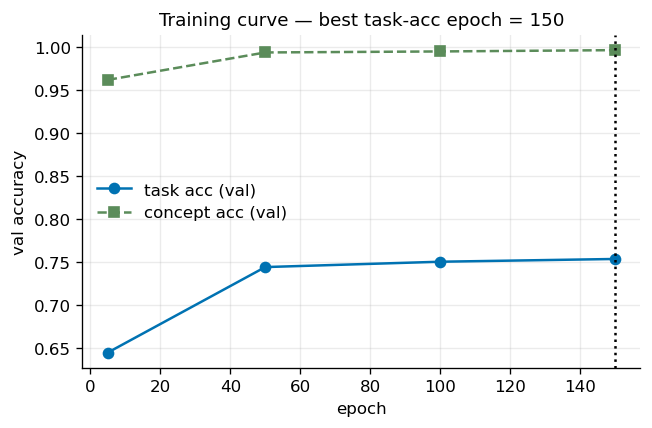

In [2]:
import re, glob, torch
SEED = 1
preds = REPO/"external"/"minimal_cbm"/"results"/"funnybirds-cbm"/str(SEED)/"predictions"
def _acc(pth):
    d = torch.load(pth, map_location="cpu")
    yp, y = d["y_preds"], d["y"]
    ta = (yp.argmax(-1)==y).float().mean().item() if yp.ndim>1 else (yp==y).float().mean().item()
    ca = None
    if d.get("c_preds") is not None and d.get("c") is not None:
        cp = d["c_preds"]; cp = cp[...,0] if cp.ndim==3 else cp
        ca = ((cp>=0.5).float()==d["c"]).float().mean().item()
    return ta, ca
files = sorted(glob.glob(str(preds/"epoch_*.pth")),
               key=lambda p:int(re.findall(r"epoch_(\d+)",p)[0]))
if not files:
    print(f"[pending] no per-epoch predictions in {preds}\n"
          "  (trainer saved only if save=True). Without them, overfitting can't be\n"
          "  read directly; compare final-epoch val acc across a couple of checkpoints.")
else:
    R = pd.DataFrame([(int(re.findall(r"epoch_(\d+)",f)[0]), *_acc(f)) for f in files],
                     columns=["epoch","task","concept"]).sort_values("epoch")
    best = int(R.loc[R.task.idxmax(),"epoch"])
    display(R.round(4))
    fig,ax=plt.subplots(figsize=(6,3.6))
    ax.plot(R.epoch, R.task, "o-", color=CBM_C, label="task acc (val)")
    if R.concept.notna().any():
        ax.plot(R.epoch, R.concept, "s--", color="#5B8C5A", label="concept acc (val)")
    ax.axvline(best, ls=":", color="k"); ax.set_xlabel("epoch"); ax.set_ylabel("val accuracy")
    ax.set_title(f"Training curve — best task-acc epoch = {best}"); ax.legend()
    tail = R[R.epoch>=best]
    drop = R.task.max() - R.task.iloc[-1]
    print(f"best task epoch={best} (acc {R.task.max():.3f}); final epoch drop from peak = {drop:+.3f}")
    print("VERDICT:", "plateau -> no overfit; late epochs are wasted compute" if abs(drop)<0.01
          else f"peaks at {best} then declines -> use epoch_{best}, later epochs overfit")

## 1 · Deletion grounding — per-part backwash
`backwash = retained P of a REMOVED part` (1 = fully backwashed, 0 = grounded).
The headline: tail retains its concept when deleted; wing/foot/beak drop to ~0.

/tmp/tmp.QS8p6ZNYUF/ipykernel_1160108/3133537882.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per = g.groupby("part").apply(agg).sort_values("backwash", ascending=False)


,n,p_intact,p_removed,backwash
part,,,,
tail,500.0,0.997,0.307,0.308
eye,500.0,0.998,0.054,0.054
beak,500.0,0.999,0.048,0.048
foot,500.0,1.000,0.010,0.010
wing,500.0,1.000,0.005,0.005


OVERALL backwash = 0.085


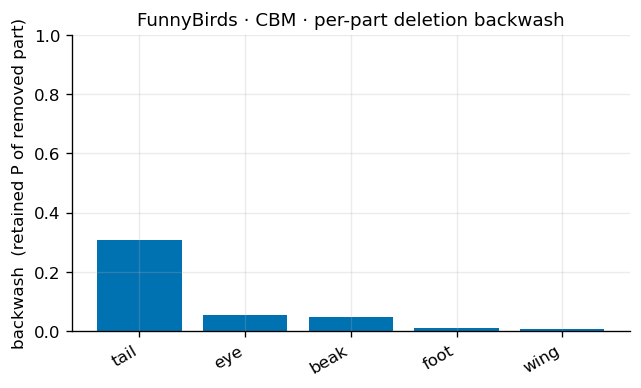

In [3]:
SEED = 1
gp = CURATED/"grounding"/f"funnybirds-cbm-s{SEED}.parquet"
if need(gp, "bash analysis/grounding_sweep.sh   (or grounding_deletion.py for one model)"):
    g = pd.read_parquet(gp)
    def agg(d):
        pi, pr = d.p_intact.mean(), d.p_removed.mean()
        gr = (pi-pr)/pi if pi>1e-6 else np.nan
        return pd.Series({"n":len(d),"p_intact":pi,"p_removed":pr,"backwash":1-gr})
    per = g.groupby("part").apply(agg).sort_values("backwash", ascending=False)
    display(per.round(3))
    fig,ax=plt.subplots(figsize=(6,3.2))
    ax.bar(per.index, per.backwash, color=CBM_C)
    ax.set_ylabel("backwash  (retained P of removed part)"); ax.set_ylim(0,1)
    ax.set_title("FunnyBirds · CBM · per-part deletion backwash"); plt.xticks(rotation=30,ha="right")
    OVERALL = 1-(g.p_intact.mean()-g.p_removed.mean())/g.p_intact.mean()
    print(f"OVERALL backwash = {OVERALL:.3f}")

## 2 · Species-identity probe — is the bottleneck a class code?
Linear probe (5-fold CV) recovering species from the bottleneck. `species←c_preds`
= how much the **reported 26-d concept vector alone** pins the species. High here
means a part concept is *answerable by class-lookup* — the standing opportunity
for backwash. Chance = 1/50 = 0.02.

chance=0.020 | species<-z 0.990 | species<-c_preds 0.996


,acc,sd,n_variants
tail,0.182,0.0040,9.0
wing,0.120,0.0000,6.0
beak,0.082,0.0040,4.0
foot,0.080,0.0000,4.0
eye,0.064,0.0049,3.0


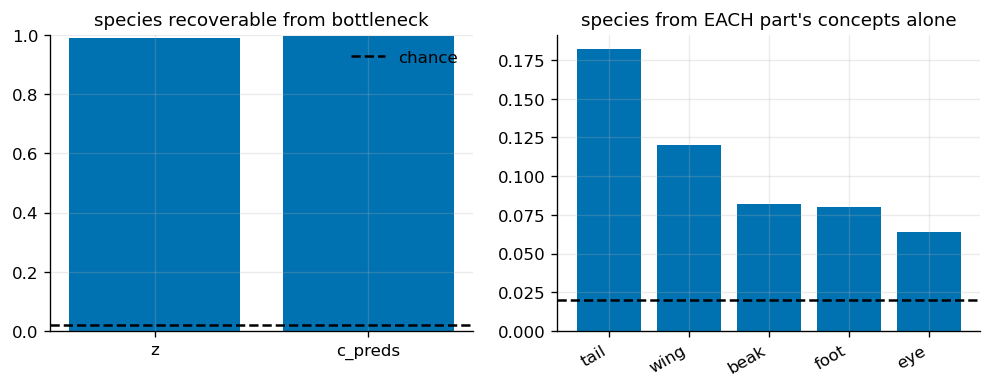

In [4]:
sp = CURATED/"species_probe"/f"funnybirds-cbm-s{SEED}.json"
PART = None
if need(sp, "bash analysis/grounding_sweep.sh   (or species_probe.py for one model)"):
    S = json.loads(sp.read_text()); ch = S["chance"]
    print(f"chance={ch:.3f} | species<-z {S['species_from_z']['acc']:.3f} | "
          f"species<-c_preds {S['species_from_cpreds']['acc']:.3f}")
    fig,ax=plt.subplots(1,2,figsize=(10,3.2))
    ax[0].bar(["z","c_preds"], [S['species_from_z']['acc'], S['species_from_cpreds']['acc']],
              color=CBM_C); ax[0].axhline(ch, ls="--", color="k", label="chance")
    ax[0].set_ylim(0,1); ax[0].set_title("species recoverable from bottleneck"); ax[0].legend()
    PART = pd.DataFrame(S["species_from_part_cpreds"]).T
    PART["acc"]=PART["acc"].astype(float); PART=PART.sort_values("acc",ascending=False)
    ax[1].bar(PART.index, PART.acc, color=CBM_C); ax[1].axhline(ch,ls="--",color="k")
    ax[1].set_title("species from EACH part's concepts alone"); plt.setp(ax[1].get_xticklabels(),rotation=30,ha="right")
    display(PART)

## 3 · Line them up — does per-part backwash track the mechanism?
Per part: measured **deletion backwash** vs **species-code** (species-from-that-part)
vs **n_variants** (concept-space size). This is correlation, not proof — the
deletion test is the causal probe; this shows whether the mechanism co-locates.

,backwash,species_code,n_variants
part,,,
tail,0.308,0.182,9.0
eye,0.054,0.064,3.0
beak,0.048,0.082,4.0
foot,0.010,0.080,4.0
wing,0.005,0.120,6.0


Read: a part high on BOTH species-code and deletion backwash = the mechanism realized.


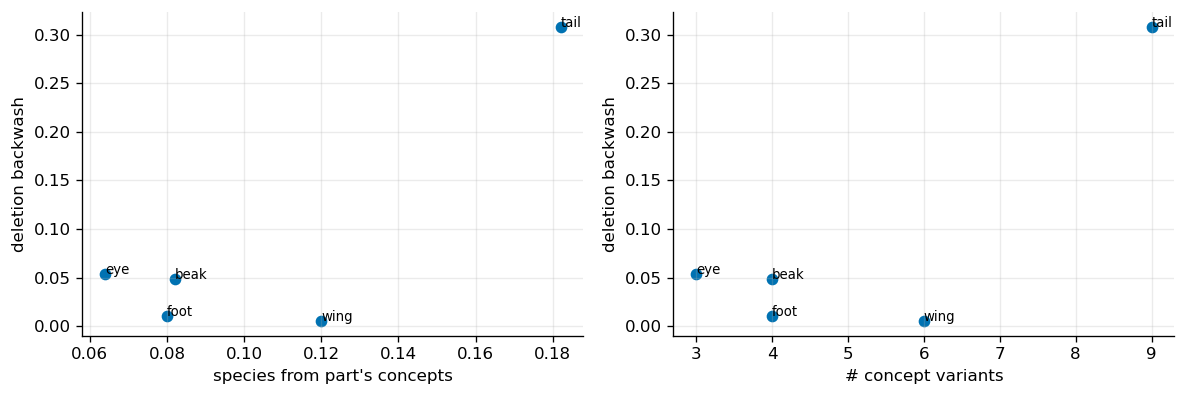

In [5]:
if 'per' in dir() and PART is not None:
    M = per[["backwash"]].join(PART[["acc","n_variants"]].rename(columns={"acc":"species_code"}))
    M["n_variants"]=M["n_variants"].astype(float); display(M.round(3))
    fig,ax=plt.subplots(1,2,figsize=(10,3.4))
    for k,(x,xl) in enumerate({"species_code":"species from part's concepts",
                               "n_variants":"# concept variants"}.items()):
        ax[k].scatter(M[x], M.backwash, color=CBM_C)
        for p,r in M.iterrows(): ax[k].annotate(p,(r[x],r.backwash),fontsize=8)
        ax[k].set_xlabel(xl); ax[k].set_ylabel("deletion backwash")
    plt.tight_layout()
    print("Read: a part high on BOTH species-code and deletion backwash = the mechanism realized.")
else:
    print("[pending] needs sections 1 and 2 to have produced outputs.")

**Takeaway.** CBM concepts are near-perfect on-distribution yet a removed part's
concept is retained (backwash), concentrated where the bottleneck most encodes
species. The next notebook asks whether MCBM's minimality removes this.